# D. 검색/벡터스토어 실험

**담당:** 벡터 DB / 유사도 검색 전략

이 노트북 하나로 **(1) 모델/전략 비교**와 **(2) 파라미터 스윕** 두 실험을 모두 진행합니다. 다른 3개 축(내 담당이 아닌 변수)은 항상 팀 공통 `BASELINE` 값으로 고정합니다.

In [1]:
# # 아래 패키지가 없다면 터미널에서 먼저 설치하세요 (주석 해제하고 실행 가능)
# %pip install ragas datasets bert-score langchain_experimental langchain_chroma faiss-cpu langchain-pinecone pinecone-client


In [16]:
# 환경 설정
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv(override=True)
plt.rcParams["axes.unicode_minus"] = False
# 한글 폰트 깨지면 아래 주석 해제 (Windows: Malgun Gothic / Mac: AppleGothic)
# plt.rcParams["font.family"] = "Malgun Gothic"

print("환경 설정 완료")


환경 설정 완료


## 팀 공통 BASELINE
4명의 노트북 모두 이 값이 동일해야 비교가 성립합니다.

In [3]:
# 팀 공통 BASELINE (4명의 노트북 모두 이 값이 동일해야 함 — 절대 개별 수정 금지)
BASELINE = {
    "chunk_size": 500,
    "chunk_overlap": 50,
    "splitter": "recursive",          # recursive / character / token / semantic
    "embedding_model": "jhgan/ko-sroberta-multitask",
    "embedding_normalize": True,
    "distance_metric": "cosine",      # cosine / l2 / ip  (Chroma hnsw:space)
    "llm_model": "Qwen/Qwen2.5-1.5B-Instruct",
    "temperature": 0,
    "search_type": "similarity",      # similarity / mmr / similarity_score_threshold
    "top_k": 3,
    "vectorstore_engine": "chroma",   # chroma / faiss
}
for k, v in BASELINE.items():
    print(f"{k}: {v}")


chunk_size: 500
chunk_overlap: 50
splitter: recursive
embedding_model: jhgan/ko-sroberta-multitask
embedding_normalize: True
distance_metric: cosine
llm_model: Qwen/Qwen2.5-1.5B-Instruct
temperature: 0
search_type: similarity
top_k: 3
vectorstore_engine: chroma


## PDF 로드

In [4]:
# PDF 로드 (청킹은 실험마다 다시 하므로, 원본 문서만 미리 로드해둠)
from langchain_community.document_loaders import PyPDFLoader

# ⚠️ TODO: 본인 PC의 자동차관리법 PDF 경로로 수정하세요.
PDF_PATH = "../data/자동차관리법.pdf"
assert os.path.exists(PDF_PATH), f"PDF 파일을 찾을 수 없습니다: {PDF_PATH}"

loader = PyPDFLoader(PDF_PATH)
raw_docs = loader.load()
print(f"로드된 페이지 수: {len(raw_docs)}")


C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_6716\2875828252.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
c:\knu-kdt\.kdtenv\Lib\site-packages\huggingface_hub\constants.py:298: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(


로드된 페이지 수: 97


## 파이프라인 빌드 함수

In [5]:
# 파이프라인 빌드 함수 (cfg = BASELINE을 덮어쓴 dict 하나를 받아 파이프라인 전체를 구성)
from langchain_text_splitters import RecursiveCharacterTextSplitter, CharacterTextSplitter, TokenTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings, HuggingFaceEndpoint, ChatHuggingFace
from langchain_chroma import Chroma
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
from langchain_huggingface import HuggingFacePipeline
import torch

PROMPT = ChatPromptTemplate.from_template(
    "다음 문맥을 근거로 질문에 답하세요. 문맥에 없는 내용은 모른다고 답하세요.\n"
    "[문맥]\n{context}\n\n[질문]\n{question}"
)

def format_docs(docs):
    return "\n\n".join(d.page_content for d in docs)

def build_splitter(cfg):
    kind = cfg["splitter"]
    if kind == "recursive":
        return RecursiveCharacterTextSplitter(chunk_size=cfg["chunk_size"], chunk_overlap=cfg["chunk_overlap"])
    elif kind == "character":
        return CharacterTextSplitter(chunk_size=cfg["chunk_size"], chunk_overlap=cfg["chunk_overlap"], separator="\n")
    elif kind == "token":
        return TokenTextSplitter(chunk_size=cfg["chunk_size"], chunk_overlap=cfg["chunk_overlap"])
    elif kind == "semantic":
        # 임베딩 기반으로 의미 단위로 자르는 전략 (langchain_experimental 필요)
        from langchain_experimental.text_splitter import SemanticChunker
        emb = build_embeddings(cfg)
        return SemanticChunker(emb)
    else:
        raise ValueError(f"알 수 없는 splitter: {kind}")

def build_embeddings(cfg):
    return HuggingFaceEmbeddings(
        model_name=cfg["embedding_model"],
        encode_kwargs={"normalize_embeddings": cfg["embedding_normalize"]},
    )

def build_vectorstore(splits, embeddings, cfg):
    if cfg["vectorstore_engine"] == "chroma":
        return Chroma.from_documents(
            documents=splits,
            embedding=embeddings,
            collection_metadata={"hnsw:space": cfg["distance_metric"]},
        )
    elif cfg["vectorstore_engine"] == "faiss":
        return FAISS.from_documents(documents=splits, embedding=embeddings)
    elif cfg["vectorstore_engine"] == "pinecone":
        from langchain_pinecone import PineconeVectorStore
        from pinecone import Pinecone, ServerlessSpec

        pc = Pinecone(api_key=os.getenv("PINECONE_API_KEY"))
        index_name = "car-act-experiment"
        existing = [idx["name"] for idx in pc.list_indexes()]
        if index_name not in existing:
            dim = len(embeddings.embed_query("dimension probe"))
            metric = cfg["distance_metric"] if cfg["distance_metric"] in ("cosine", "euclidean", "dotproduct") else "cosine"
            pc.create_index(
                name=index_name, dimension=dim, metric=metric,
                spec=ServerlessSpec(cloud="aws", region="us-east-1"),
            )
            time.sleep(10)  # 인덱스 생성 대기
        return PineconeVectorStore.from_documents(documents=splits, embedding=embeddings, index_name=index_name)
    else:
        raise ValueError(f"알 수 없는 벡터스토어: {cfg['vectorstore_engine']}")

def build_retriever(vectorstore, cfg):
    if cfg["search_type"] == "similarity_score_threshold":
        return vectorstore.as_retriever(
            search_type="similarity_score_threshold",
            search_kwargs={"k": cfg["top_k"], "score_threshold": 0.5},
        )
    elif cfg["search_type"] == "mmr":
        return vectorstore.as_retriever(
            search_type="mmr",
            search_kwargs={"k": cfg["top_k"], "fetch_k": max(cfg["top_k"] * 2, 10)},
        )
    else:
        return vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": cfg["top_k"]})

def build_llm(cfg):
    pipe = HuggingFacePipeline.from_model_id(
        model_id=cfg["llm_model"],
        task="text-generation",
        pipeline_kwargs={
            "max_new_tokens": 512,
            "temperature": cfg["temperature"] if cfg["temperature"] > 0 else 0.01,
            "do_sample": cfg["temperature"] > 0,
        },
        device_map="auto" if torch.cuda.is_available() else None,
    )
    return ChatHuggingFace(llm=pipe)

def build_pipeline(cfg):
    splitter = build_splitter(cfg)
    splits = splitter.split_documents(raw_docs)
    embeddings = build_embeddings(cfg)
    vectorstore = build_vectorstore(splits, embeddings, cfg)
    retriever = build_retriever(vectorstore, cfg)
    llm = build_llm(cfg)
    return retriever, llm

print("헬퍼 함수 정의 완료")


헬퍼 함수 정의 완료


## 평가 데이터셋

In [6]:
# 평가 데이터셋 — 팀 공통 (4명 전원 반드시 동일하게 사용)
# 국가법령정보센터 등 공개 조문을 참고하여 작성함. 최종 제출 전 law.go.kr에서 현행 조문과 한 번 더 대조 권장.
eval_data = [
    {
        "question": "자동차관리법상 '자동차'의 정의는 무엇인가?",
        "ground_truth": "원동기로 육상을 이동할 목적으로 제작한 용구 또는 그것에 견인되어 육상을 이동하는 피견인자동차를 말하며, 대통령령으로 정하는 것은 제외한다 (제2조 제1호).",
    },
    {
        "question": "자동차관리법상 '운행'이란 무엇을 의미하는가?",
        "ground_truth": "사람 또는 화물의 운송 여부와 관계없이 자동차를 그 용법에 따라 사용하는 것을 말한다 (제2조 제2호).",
    },
    {
        "question": "'자동차사용자'는 누구를 말하는가?",
        "ground_truth": "자동차 소유자 또는 자동차 소유자로부터 자동차 운행 등에 관한 사항을 위탁받은 자를 말한다 (제2조 제3호).",
    },
    {
        "question": "'자율주행자동차'의 정의는 무엇인가?",
        "ground_truth": "운전자 또는 승객의 조작 없이 자동차 스스로 운행이 가능한 자동차를 말한다 (제2조 제1호의3).",
    },
    {
        "question": "자동차를 운행하려면 어떤 절차를 거쳐야 하는가?",
        "ground_truth": "이륜자동차를 제외한 자동차는 자동차등록원부에 등록한 후가 아니면 운행할 수 없다. 다만 임시운행허가를 받아 그 기간 내에 운행하는 경우는 예외이다 (제5조).",
    },
    {
        "question": "자동차 소유권의 이전은 언제 효력이 생기는가?",
        "ground_truth": "자동차 소유권의 득실변경은 등록을 하여야 그 효력이 생긴다 (제6조).",
    },
    {
        "question": "등록하지 않은 자동차를 임시로 운행하려면 어떻게 해야 하는가?",
        "ground_truth": "국토교통부장관 또는 시·도지사의 임시운행허가를 받아야 한다 (제27조 제1항).",
    },
    {
        "question": "자동차검사의 종류에는 어떤 것들이 있는가?",
        "ground_truth": "신규검사, 정기검사, 튜닝검사, 임시검사 등이 있다 (제43조).",
    },
    {
        "question": "'정기검사'란 무엇인가?",
        "ground_truth": "신규등록 후 일정 기간마다 정기적으로 실시하는 검사를 말한다 (제43조 제1항 제2호).",
    },
    {
        "question": "자동차종합검사란 무엇인가?",
        "ground_truth": "정기검사, 배출가스 정밀검사, 특정경유자동차 검사를 하나로 통합해서 실시하는 검사제도이다 (제43조의2).",
    },
]
print(f"평가 질문 수: {len(eval_data)}개")


평가 질문 수: 10개


## RAGAS judge 모델

In [17]:
# RAGAS 평가용 judge LLM/Embedding (강의 예제와 동일하게 OpenAI 사용 — .env에 OPENAI_API_KEY 필요)
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

judge_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
judge_embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
print("RAGAS judge 모델 준비 완료")


RAGAS judge 모델 준비 완료


## 실험 실행 함수 (BERTScore + RAGAS + 응답시간 + Hallucination)

In [8]:
# 실험 1회 실행 함수: cfg를 받아 파이프라인을 만들고, eval_data 전체에 대해 답변+지표를 계산
from bert_score import score as bertscore
from ragas import evaluate as ragas_evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
from datasets import Dataset

def run_experiment(cfg, label):
    print(f"\n=== 실행: {label} ===")
    retriever, llm = build_pipeline(cfg)

    questions, answers, contexts, ground_truths, times = [], [], [], [], []
    for item in eval_data:
        q = item["question"]
        start = time.time()
        docs = retriever.invoke(q)
        context_text = format_docs(docs)
        msg = PROMPT.invoke({"context": context_text, "question": q})
        response = llm.invoke(msg)
        answer = response.content if hasattr(response, "content") else str(response)
        elapsed = time.time() - start

        questions.append(q)
        answers.append(answer)
        contexts.append([d.page_content for d in docs])
        ground_truths.append(item["ground_truth"])
        times.append(elapsed)

    df = pd.DataFrame({
        "question": questions,
        "ground_truth": ground_truths,
        "answer": answers,
        "response_time_sec": times,
    })

    # BERTScore (필수)
    P, R, F1 = bertscore(answers, ground_truths, 
                         model_type="klue/bert-base", 
                         num_layers=12,
                         lang="ko", 
                         verbose=False)
    df["bertscore_f1"] = F1.tolist()

    # RAGAS
    ragas_ds = Dataset.from_dict({
        "user_input": questions,
        "response": answers,
        "retrieved_contexts": contexts,
        "reference": ground_truths,
    })
    ragas_result = ragas_evaluate(
        dataset=ragas_ds,
        metrics=[faithfulness, answer_relevancy, context_precision, context_recall],
        llm=judge_llm,
        embeddings=judge_embeddings,
    )
    ragas_df = ragas_result.to_pandas()
    for col in ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]:
        if col in ragas_df.columns:
            df[col] = ragas_df[col].values

    # Hallucination — 팀원이 직접 확인 후 True/False로 수정
    df["hallucination"] = False

    summary = {
        "label": label,
        **{k: cfg[k] for k in cfg},
        "bertscore_f1": df["bertscore_f1"].mean(),
        "faithfulness": df.get("faithfulness", pd.Series(dtype=float)).mean(),
        "answer_relevancy": df.get("answer_relevancy", pd.Series(dtype=float)).mean(),
        "context_precision": df.get("context_precision", pd.Series(dtype=float)).mean(),
        "context_recall": df.get("context_recall", pd.Series(dtype=float)).mean(),
        "response_time_sec": df["response_time_sec"].mean(),
        "hallucination_count": df["hallucination"].sum(),
    }

    os.makedirs("./eval", exist_ok=True)
    df.to_csv(f"./eval/detail_{label}.csv", index=False, encoding="utf-8-sig")
    print(f"BERTScore F1: {summary['bertscore_f1']:.4f} | faithfulness: {summary['faithfulness']:.4f} | 응답시간: {summary['response_time_sec']:.2f}s")
    return summary

print("run_experiment() 정의 완료")


run_experiment() 정의 완료


C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_6716\945416684.py:4: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_6716\945416684.py:4: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_6716\945416684.py:4: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: f

In [9]:
def save_and_plot(rows, group_name, x_key, x_label):
    df = pd.DataFrame(rows)
    df.to_csv(f"./eval/summary_{group_name}.csv", index=False, encoding="utf-8-sig")
    display(df)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(df["label"], df["bertscore_f1"], color="#4C72B0")
    axes[0].set_title(f"{group_name} — BERTScore F1")
    axes[0].tick_params(axis="x", rotation=30)

    axes[1].bar(df["label"], df["response_time_sec"], color="#DD8452")
    axes[1].set_title(f"{group_name} — 평균 응답시간(초)")
    axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.savefig(f"./eval/plot_{group_name}.png", dpi=150)
    plt.show()
    return df

print("save_and_plot() 정의 완료")


save_and_plot() 정의 완료


## 실험 1 — 검색 전략/엔진 비교 (baseline 포함 6개)
다른 축(파라미터 등)은 전부 BASELINE 값으로 고정.


=== 실행: baseline_similarity_chroma ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-proce

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Exception raised in Job[12]: AuthenticationError(Error code: 401 - {'error': {'message': 'Incorrect API key provided: ssk-proj*********************************************************************************************************************************************************ezQA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}})
Exception raised in Job[13]: AuthenticationError(Error code: 401 - {'error': {'message': 'Incorrect API key provided: ssk-proj*********************************************************************************************************************************************************ezQA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}})
Exception raised in Job[15]: AuthenticationError(Error code: 401 - {'error': {'message': 'Incorrect API key provided: ssk-

BERTScore F1: 0.5244 | faithfulness: nan | 응답시간: 25.50s


,label,chunk_size,chunk_overlap,splitter,embedding_model,embedding_normalize,distance_metric,llm_model,temperature,search_type,top_k,vectorstore_engine,bertscore_f1,faithfulness,answer_relevancy,context_precision,context_recall,response_time_sec,hallucination_count
0,baseline_similarity_chroma,500,50,recursive,jhgan/ko-sroberta-multitask,True,cosine,Qwen/Qwen2.5-1.5B-Instruct,0,similarity,3,chroma,0.524362,NaN,NaN,NaN,NaN,25.089709,0
1,mmr_chroma,500,50,recursive,jhgan/ko-sroberta-multitask,True,cosine,Qwen/Qwen2.5-1.5B-Instruct,0,mmr,3,chroma,0.528787,NaN,NaN,NaN,NaN,27.916707,0
2,score_threshold_chroma,500,50,recursive,jhgan/ko-sroberta-multitask,True,cosine,Qwen/Qwen2.5-1.5B-Instruct,0,similarity_score_threshold,3,chroma,0.495930,NaN,NaN,NaN,NaN,20.114859,0
3,similarity_faiss,500,50,recursive,jhgan/ko-sroberta-multitask,True,cosine,Qwen/Qwen2.5-1.5B-Instruct,0,similarity,3,faiss,0.524362,NaN,NaN,NaN,NaN,25.552064,0
4,mmr_faiss,500,50,recursive,jhgan/ko-sroberta-multitask,True,cosine,Qwen/Qwen2.5-1.5B-Instruct,0,mmr,3,faiss,0.521199,NaN,NaN,NaN,NaN,23.499268,0
5,similarity_pinecone,500,50,recursive,jhgan/ko-sroberta-multitask,True,cosine,Qwen/Qwen2.5-1.5B-Instruct,0,similarity,3,pinecone,0.524362,NaN,NaN,NaN,NaN,25.500018,0


C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_6716\2600946732.py:15: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_6716\2600946732.py:15: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_6716\2600946732.py:15: UserWarning: Glyph 51025 (\N{HANGUL SYLLABLE EUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_6716\2600946732.py:15: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_6716\2600946732.py:15: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_6716\2600946732.py:15: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE G

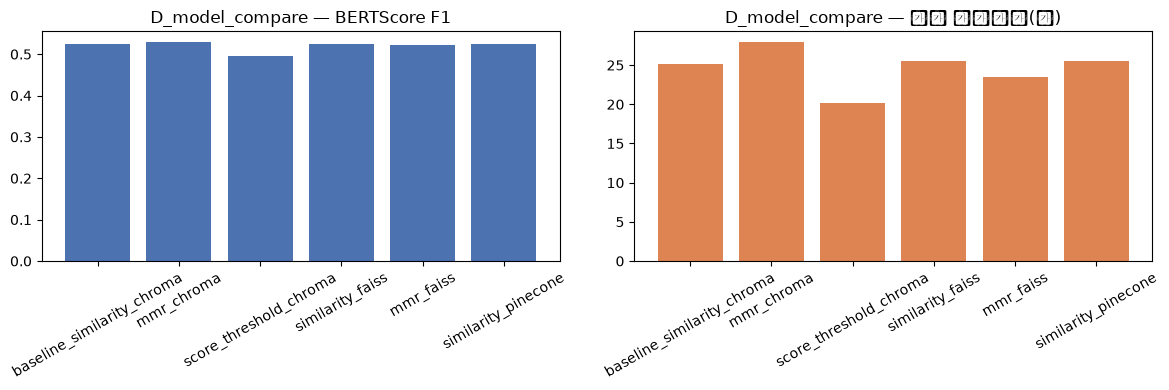

In [10]:
# 비교할 검색 전략 x 벡터스토어 엔진 6개 (baseline 포함)
# ⚠️ pinecone 사용시 .env에 PINECONE_API_KEY 필요, 무료 플랜은 인덱스 생성 후 첫 실행에 시간이 좀 걸릴 수 있음
CANDIDATES = {
    "baseline_similarity_chroma": {},   # ← 이거 다시 추가
    "mmr_chroma":                  {"search_type": "mmr"},
    "score_threshold_chroma":      {"search_type": "similarity_score_threshold"},
    "similarity_faiss":            {"vectorstore_engine": "faiss"},
    "mmr_faiss":                    {"search_type": "mmr", "vectorstore_engine": "faiss"},
    "similarity_pinecone":          {"vectorstore_engine": "pinecone"},
}

rows = []
for label, overrides in CANDIDATES.items():
    cfg = dict(BASELINE)
    cfg.update(overrides)
    rows.append(run_experiment(cfg, label))

df_model = save_and_plot(rows, "D_model_compare", None, None)


## 실험 2 — 유사도 계산 방식 x top_k 스윕 (5개 값)
모델/전략은 BASELINE 값으로 고정하고, 이 파라미터만 바꿔가며 실행.


=== 실행: cosine_k3 ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Exception raised in Job[8]: AuthenticationError(Error code: 401 - {'error': {'message': 'Incorrect API key provided: ssk-proj*********************************************************************************************************************************************************ezQA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}})
Exception raised in Job[15]: AuthenticationError(Error code: 401 - {'error': {'message': 'Incorrect API key provided: ssk-proj*********************************************************************************************************************************************************ezQA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}})
Exception raised in Job[1]: AuthenticationError(Error code: 401 - {'error': {'message': 'Incorrect API key provided: ssk-pr

BERTScore F1: 0.4952 | faithfulness: nan | 응답시간: 40.86s


,label,chunk_size,chunk_overlap,splitter,embedding_model,embedding_normalize,distance_metric,llm_model,temperature,search_type,top_k,vectorstore_engine,bertscore_f1,faithfulness,answer_relevancy,context_precision,context_recall,response_time_sec,hallucination_count
0,cosine_k3,500,50,recursive,jhgan/ko-sroberta-multitask,True,cosine,Qwen/Qwen2.5-1.5B-Instruct,0,similarity,3,chroma,0.495930,NaN,NaN,NaN,NaN,20.154651,0
1,l2_k3,500,50,recursive,jhgan/ko-sroberta-multitask,True,l2,Qwen/Qwen2.5-1.5B-Instruct,0,similarity,3,chroma,0.495930,NaN,NaN,NaN,NaN,19.780983,0
2,ip_k3,500,50,recursive,jhgan/ko-sroberta-multitask,True,ip,Qwen/Qwen2.5-1.5B-Instruct,0,similarity,3,chroma,0.495930,NaN,NaN,NaN,NaN,19.646665,0
3,cosine_k5,500,50,recursive,jhgan/ko-sroberta-multitask,True,cosine,Qwen/Qwen2.5-1.5B-Instruct,0,similarity,5,chroma,0.495156,NaN,NaN,NaN,NaN,24.297759,0
4,cosine_k10,500,50,recursive,jhgan/ko-sroberta-multitask,True,cosine,Qwen/Qwen2.5-1.5B-Instruct,0,similarity,10,chroma,0.495156,NaN,NaN,NaN,NaN,40.864221,0


C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_6716\2600946732.py:15: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_6716\2600946732.py:15: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_6716\2600946732.py:15: UserWarning: Glyph 51025 (\N{HANGUL SYLLABLE EUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_6716\2600946732.py:15: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_6716\2600946732.py:15: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_6716\2600946732.py:15: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE G

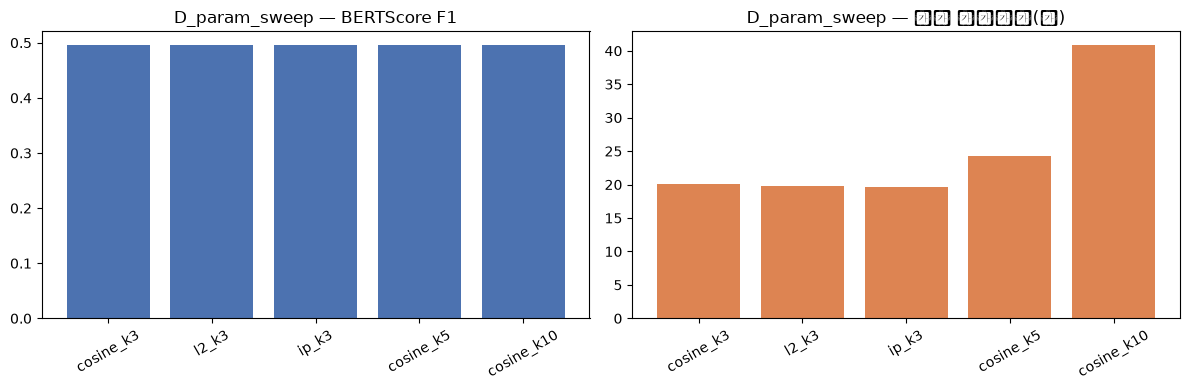

In [11]:
# 유사도 계산 방식(distance_metric) x top_k 조합 5가지 (검색 전략/엔진은 baseline=similarity/Chroma 고정)
# "검색/유사도" 담당이므로 top_k만이 아니라 유사도 계산 방식도 함께 실험
CANDIDATES = {
    "cosine_k3":   {"distance_metric": "cosine", "top_k": 3},   # baseline과 동일
    "l2_k3":       {"distance_metric": "l2",     "top_k": 3},
    "ip_k3":       {"distance_metric": "ip",     "top_k": 3},
    "cosine_k5":   {"distance_metric": "cosine", "top_k": 5},
    "cosine_k10":  {"distance_metric": "cosine", "top_k": 10},
}

rows = []
for label, overrides in CANDIDATES.items():
    cfg = dict(BASELINE)
    cfg.update(overrides)
    rows.append(run_experiment(cfg, label))

df_param = save_and_plot(rows, "D_param_sweep", None, None)


## 최적 조합 저장

In [12]:
ROLE_NAME = "D"
# 두 실험(모델 비교 + 파라미터 스윕) 통틀어 가장 좋은 조합을 best_{ROLE}.csv로 저장
combined = pd.concat([df_model, df_param], ignore_index=True)
best_row = combined.sort_values("bertscore_f1", ascending=False).iloc[[0]]
best_row.to_csv(f"./eval/best_{ROLE_NAME}.csv", index=False, encoding="utf-8-sig")
print("=== 이 역할에서 찾은 최적 조합 ===")
best_row


=== 이 역할에서 찾은 최적 조합 ===


,label,chunk_size,chunk_overlap,splitter,embedding_model,embedding_normalize,distance_metric,llm_model,temperature,search_type,top_k,vectorstore_engine,bertscore_f1,faithfulness,answer_relevancy,context_precision,context_recall,response_time_sec,hallucination_count
1,mmr_chroma,500,50,recursive,jhgan/ko-sroberta-multitask,True,cosine,Qwen/Qwen2.5-1.5B-Instruct,0,mmr,3,chroma,0.528787,NaN,NaN,NaN,NaN,27.916707,0


In [18]:
from ragas import evaluate as ragas_evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
from datasets import Dataset
import pandas as pd

def fix_ragas_only(csv_path):
    df = pd.read_csv(csv_path)
    # detail 파일엔 context가 없으니, ground_truth/answer로만 되는 지표는 재계산 가능
    ragas_ds = Dataset.from_dict({
        "user_input": df["question"].tolist(),
        "response": df["answer"].tolist(),
        "reference": df["ground_truth"].tolist(),
    })
    result = ragas_evaluate(
        dataset=ragas_ds,
        metrics=[answer_relevancy],  # context_precision/recall/faithfulness는 context 필요해서 제외
        llm=judge_llm,
        embeddings=judge_embeddings,
    )
    return result.to_pandas()

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_6716\1736496813.py:2: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_6716\1736496813.py:2: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_6716\1736496813.py:2: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example

In [ ]:
# D 실험 1(모델 비교) 결과들에 대해 RAGAS 재계산
import glob

detail_files = glob.glob("./eval/detail_*.csv")
print(f"찾은 파일: {len(detail_files)}개")

for f in detail_files:
    print(f"\n처리 중: {f}")
    result_df = fix_ragas_only(f)
    print(result_df[["answer_relevancy"]].mean())

찾은 파일: 11개

처리 중: ./eval\detail_baseline_similarity_chroma.csv


Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

Exception raised in Job[2]: RateLimitError(Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}})
Exception raised in Job[4]: RateLimitError(Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}})
Exception raised in Job[9]: RateLimitError(Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'ins

answer_relevancy   NaN
dtype: float64

처리 중: ./eval\detail_cosine_k10.csv


Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

Exception raised in Job[9]: RateLimitError(Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}})
Exception raised in Job[1]: RateLimitError(Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}})
Exception raised in Job[6]: RateLimitError(Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'ins

## 결과 해석 (직접 작성)

- 실험 1에서 baseline 대비 가장 좋았던 것은? 왜 그런 결과가 나왔다고 생각하나요?
- 실험 2에서 값이 커지거나 작아질수록 어떤 경향이 보였나요? (예: 성능은 좋아지지만 응답시간이 늘어나는 trade-off 등)
- 최종적으로 팀 챗봇에 반영을 추천하는 조합과 그 근거를 적으세요.

> TODO: 위 질문에 대한 답을 이 셀 아래에 markdown으로 작성하세요.